---

## Installing and importing dependencies for the project

In [ ]:
#dont run!!!
%pip uninstall mediapipe -y

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
print(sys.version) #need python 3.11.9
print(sys.maxsize > 2**32) #Python architecture:64-bit (True) or 32-bit (False)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
True


In [2]:
%pip install opencv-python scikit-learn mediapipe==0.10.14 matplotlib tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importing them
import time 
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
import mediapipe as mp


---

## Keypoints (MP Holistic) 
1. Check and confirm web came availability using opencv.
2. Detections will then be made using mediapipe.

In [4]:
#Mediapipe holistic model
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic()

#Mediapipe drawing utils
mp_drawing = mp.solutions.drawing_utils

In [5]:
# function: to make detections (convert from bgr to rgb then make img not writeable. make prediction then make the image writeable before converting rgb to bgr)
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    image.flags.writeable = False                  
    results = model.process(image)                 
    image.flags.writeable = True                   
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) 
    return image, results

### MediaPipe Landmark Connection Reference

* **`mp_holistic.POSE_CONNECTIONS` (Indices 0–32)**
  * **Face:** 0 (Nose), 1-3 (L Eye), 4-6 (R Eye), 7-8 (Ears), 9-10 (Mouth)
  * **Upper Body:** 11-12 (Shoulders), 13-14 (Elbows), 15-16 (Wrists)
  * **Hands:** 17, 19, 21 (L Hand digits) | 18, 20, 22 (R Hand digits)
  * **Lower Body:** 23-24 (Hips), 25-26 (Knees), 27-28 (Ankles), 29-32 (Heels/Toes)

* **`mp_holistic.HAND_CONNECTIONS` (Indices 0–20)**
  * **Base:** 0 (Wrist)
  * **Digits (Base to Tip):** 1-4 (Thumb), 5-8 (Index), 9-12 (Middle), 13-16 (Ring), 17-20 (Pinky)

* **`mp_holistic.FACEMESH_CONTOURS` (Indices 0–467)**
  * Tracks 468 dense facial points grouped into loops:
  * **Lips:** Outer (61–375) | Inner (78–402)
  * **Eyes & Brows:** Left (33–163 eye, 70–105 brow) | Right (263–398 eye, 300–334 brow)
  * **Face Oval:** Outer jaw and hairline silhouette (10 to 152 loop)

In [6]:
# function: to draw the landmarks
def landmarks_draw(image, results):
    # 1. Draw Face Landmarks (FACEMESH_CONTOURS:outlines eyes lips and face shape  [or] FACEMESH_TESSELATION: forms a mesh over the entire face)
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.face_landmarks, 
            mp_holistic.FACEMESH_CONTOURS,
            mp_drawing.DrawingSpec(color= (204,102,0), thickness=1, circle_radius=1), #bgr format, landmark
            mp_drawing.DrawingSpec(color= (255,0,255), thickness=1, circle_radius=1) #connecting parts
        )
        
    # 2. Draw Pose Landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color= (204,0,102), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color= (0,255,0), thickness=2, circle_radius=2)
        )
        
    # 3. Draw Right Hand Landmarks (Using mp_holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color= (0,255,255), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color= (0,0,255), thickness=2, circle_radius=2)
        )

    # 4. Draw Left Hand Landmarks (Using mp_holistic.HAND_CONNECTIONS)
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color= (0,128,255), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color= (0,0,255), thickness=2, circle_radius=2)
        )

In [7]:
#Access webcam (device 0). cap reads the feed from webcam and stores it.
cap = cv2.VideoCapture(0)

#access holistic model (detect then track)
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
    #read feed (ret = return value (boolean), frame = image array)
        ret, frame = cap.read()

        #make detections
        image,results = mediapipe_detection(frame, holistic)
        print(results)

        #draw landmarks
        landmarks_draw(image, results)

        #show
        if ret!= True:
            print("Error reading frame from webcam. Exiting...")
            break
        else:
            cv2.imshow("Sign_Language_Detection", image)

        #if the key 'q' is pressed inside of the frame, exit the loop
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release() 
    cv2.destroyAllWindows() 

c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_vid_detection\.venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

### Testing by frame (for testing in case the above code block has some issues. if fine, don't need to run the 8 code blocks after this)

In [165]:
#face landmarks
results.face_landmarks
len(results.face_landmarks.landmark)


468

In [166]:
#right_hand landmarks
results.right_hand_landmarks
len(results.right_hand_landmarks.landmark)

AttributeError: 'NoneType' object has no attribute 'landmark'

In [167]:
#left_hand landmarks
results.right_hand_landmarks
len(results.left_hand_landmarks.landmark)

21

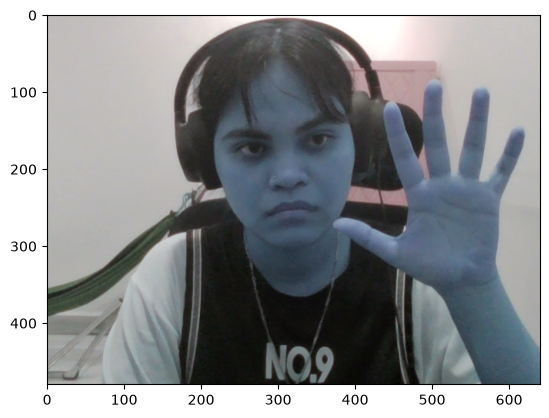

In [168]:
plt.imshow(frame)

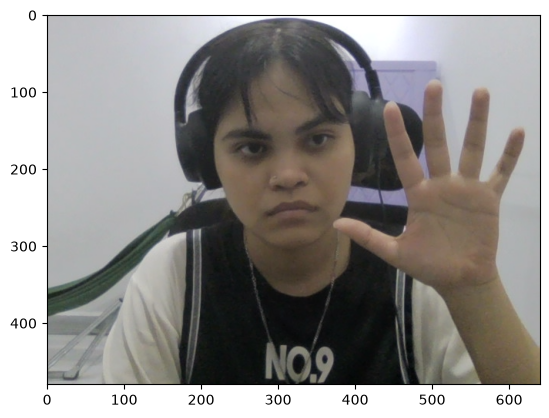

In [169]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [170]:
landmarks_draw(frame, results)

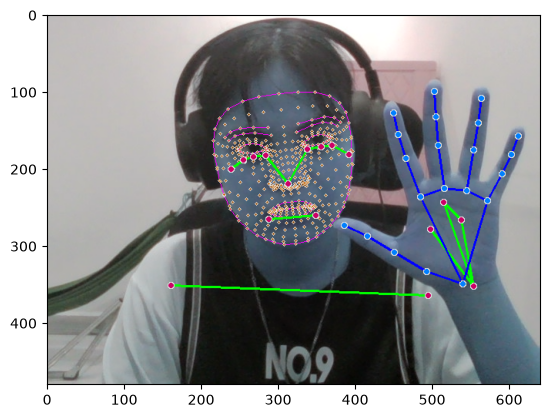

In [171]:
plt.imshow(frame)

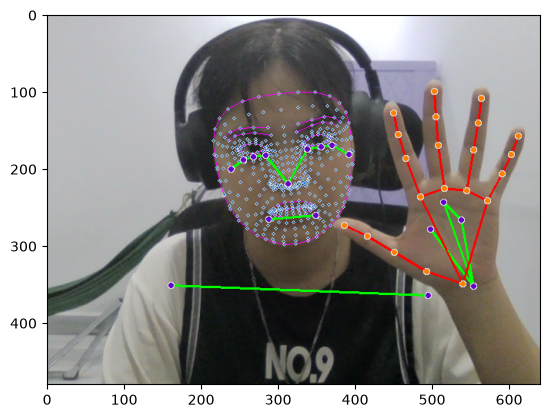

In [172]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

---

## Extract keypoint values

Create numpy array to store the coordinates.

### One by one for testing

In [180]:
#pose array
pose = []

if results.pose_landmarks:
    for res in results.pose_landmarks.landmark:
        vals= np.array([res.x, res.y, res.z, res.visibility])
        pose.append(vals)

    pose = np.array(pose).flatten()

else:
    pose = np.zeros(132)

In [181]:
len (pose)

132

In [182]:
pose

array([ 4.89467233e-01,  4.58170384e-01, -1.20328283e+00,  9.99831021e-01,
        5.28125405e-01,  3.63066852e-01, -1.17801321e+00,  9.99675453e-01,
        5.56708813e-01,  3.57110620e-01, -1.17857552e+00,  9.99807298e-01,
        5.78830659e-01,  3.53077114e-01, -1.17868733e+00,  9.99725521e-01,
        4.45172012e-01,  3.79855067e-01, -1.15143156e+00,  9.99477088e-01,
        4.20205176e-01,  3.85395736e-01, -1.15031159e+00,  9.99497890e-01,
        3.99389446e-01,  3.92493308e-01, -1.15054905e+00,  9.99102831e-01,
        6.12579107e-01,  3.77318710e-01, -8.06013227e-01,  9.99833465e-01,
        3.73592913e-01,  4.16924208e-01, -6.69911623e-01,  9.99762416e-01,
        5.46647370e-01,  5.42120576e-01, -1.05553341e+00,  9.99864936e-01,
        4.50940371e-01,  5.52909851e-01, -1.01716304e+00,  9.99824703e-01,
        7.74348378e-01,  7.59342551e-01, -4.63286310e-01,  9.99485731e-01,
        2.52422720e-01,  7.32074618e-01, -1.69710428e-01,  9.95300591e-01,
        1.03923500e+00,  

In [183]:
#face array
face = []

if results.face_landmarks:
    for res in results.face_landmarks.landmark:
        fvals = np.array([res.x, res.y, res.z])
        face.append(fvals)
        
    face = np.array(face).flatten()
else:
    face= np.zeros(1404)

In [186]:
face

array([ 0.49767399,  0.50786638, -0.0340249 , ...,  0.57865381,
        0.32506609,  0.01719214])

In [176]:
#left_hand array
left_hand = []

if results.left_hand_landmarks:
    for res in results.left_hand_landmarks.landmark:
        lhvals = np.array([res.x, res.y, res.z])
        left_hand.append(lhvals)
        
    left_hand = np.array(left_hand).flatten()
else:
    left_hand= np.zeros(21*3)

In [177]:
left_hand

array([ 8.44011247e-01,  7.28323460e-01,  5.62154810e-07,  7.70920992e-01,
        6.94846272e-01, -3.40005048e-02,  7.04842091e-01,  6.43490195e-01,
       -5.51478863e-02,  6.50953472e-01,  5.97951770e-01, -7.34700859e-02,
        6.04008317e-01,  5.69218814e-01, -9.25138816e-02,  7.57878065e-01,
        4.93267119e-01, -3.86683084e-02,  7.29561150e-01,  3.88824761e-01,
       -6.36386648e-02,  7.13835001e-01,  3.23839277e-01, -8.34108815e-02,
        7.04615295e-01,  2.64591932e-01, -9.88138020e-02,  8.06733608e-01,
        4.70688790e-01, -4.24953587e-02,  7.94749200e-01,  3.53060693e-01,
       -6.44850060e-02,  7.89534271e-01,  2.76015371e-01, -8.40984955e-02,
        7.87236869e-01,  2.07951605e-01, -9.96527076e-02,  8.52851689e-01,
        4.76306021e-01, -5.05964458e-02,  8.66327047e-01,  3.65678370e-01,
       -7.82497376e-02,  8.75673771e-01,  2.91732132e-01, -9.96860042e-02,
        8.82019699e-01,  2.25744039e-01, -1.14813052e-01,  8.94455314e-01,
        5.03617048e-01, -

In [178]:
#right_hand array
right_hand = []

if results.right_hand_landmarks:
    for res in results.right_hand_landmarks.landmark:
        rtvals = np.array([res.x, res.y, res.z])
        right_hand.append(rtvals)
        
    right_hand = np.array(right_hand).flatten()
else:
    right_hand= np.zeros(21*3)

In [179]:
right_hand

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

### All in one

In [187]:
def extract_keypoints(results):
    #pose array
    pose = []

    if results.pose_landmarks:
        for res in results.pose_landmarks.landmark:
            vals= np.array([res.x, res.y, res.z, res.visibility])
            pose.append(vals)

        pose = np.array(pose).flatten()

    else:
        pose = np.zeros(132)

    
    #face array
    face = []

    if results.face_landmarks:
        for res in results.face_landmarks.landmark:
            fvals = np.array([res.x, res.y, res.z])
            face.append(fvals)
            
        face = np.array(face).flatten()
    else:
        face= np.zeros(1404)

    
    #right_hand array
    right_hand = []

    if results.right_hand_landmarks:
        for res in results.right_hand_landmarks.landmark:
            rtvals = np.array([res.x, res.y, res.z])
            right_hand.append(rtvals)
            
        right_hand = np.array(right_hand).flatten()
    else:
        right_hand= np.zeros(21*3)


    #left_hand array
    left_hand = []

    if results.left_hand_landmarks:
        for res in results.left_hand_landmarks.landmark:
            lhvals = np.array([res.x, res.y, res.z])
            left_hand.append(lhvals)
            
        left_hand = np.array(left_hand).flatten()
    else:
        left_hand= np.zeros(21*3)
    